In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import maps

# discretize functionality
from discretize import TensorMesh, TreeMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import tarfile
from pathlib import Path

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

save_output = False  # Optional, (No Idea..)

#Fix path to data directory
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

### Read in data
We have four data files:
- obs.mag
- sus.mod
- sus.msh
- topo.dat

obs.mag is five columns organized as the following (containing total field oberservations):

X       Y       Z       DATA_VALUE    ERROR

sus.mod is one column of susceptibiity values

sus.msh decribes the tensor mesh

topo.dat is three columns, describing the topography as such:

X       Y       Z

In [26]:
def read_obs_mag(filename):
    data = np.loadtxt(DATA_DIR / filename, skiprows=3)

    df = pd.DataFrame(data, columns=["X", "Y", "Z", "MAG", "ERR"])
    return df

def read_topo(filename):
    data = np.loadtxt(DATA_DIR / filename, skiprows=1)

    df = pd.DataFrame(data, columns=["X", "Y", "Z"])
    return df

def read_model(filename):
    data = np.loadtxt(DATA_DIR / filename)

    df = pd.DataFrame(data, columns=['sus'])
    return df

def read_tensor_mesh(file):
    with open(file, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

    nx, ny, nz = map(int, lines[0].split())
    x0, y0, z0 = map(float, lines[1].split())

    def parse(line):
        n, v = line.split("*")
        return int(n), float(v)

    nx2, dx = parse(lines[2])
    ny2, dy = parse(lines[3])
    nz2, dz = parse(lines[4])

    assert (nx, ny, nz) == (nx2, ny2, nz2)

    return {
        "nx": nx, "ny": ny, "nz": nz,
        "x0": x0, "y0": y0, "z0": z0,
        "dx": dx, "dy": dy, "dz": dz
    }


In [28]:
observations = read_obs_mag("obs.mag")
topography = read_topo("topo.dat")
model = read_model("sus.mod")
mesh_data = read_tensor_mesh(DATA_DIR / "sus.msh")

In [30]:
print(observations.shape)
print(topography.shape)
print(model.shape)
print(mesh_data)

(2009, 5)
(2009, 3)
(69120, 1)
{'nx': 48, 'ny': 40, 'nz': 36, 'x0': 12300.0, 'y0': 9000.0, 'z0': 1150.0, 'dx': 25.0, 'dy': 25.0, 'dz': 12.5}


### Plot Topography

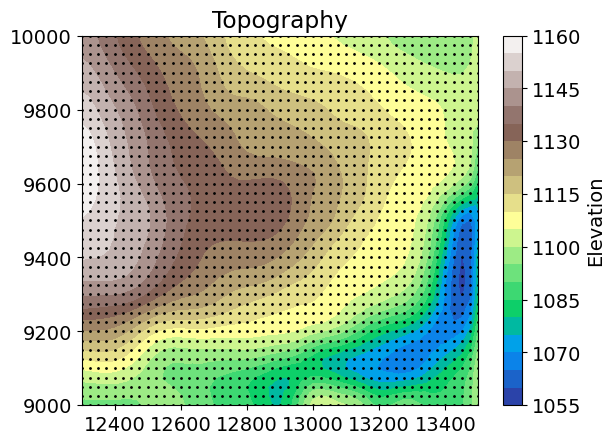

In [ ]:
x_topo = topography['X'].values
y_topo = topography['Y'].values
z_topo = topography['Z'].values

plt.tricontourf(x_topo, y_topo, z_topo, levels=20, cmap="terrain")
plt.colorbar(label="Elevation")
plt.scatter(x_topo, y_topo, c="k", s=1)
plt.title("Topography")
plt.show()

                      

### Define Observation locations

In [37]:
#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x = observations['X'].values
y = observations['Y'].values

fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y])  # Ground Survey

mask = ~np.isnan(z) #be careful of NANs from the interpolation
receiver_locations = np.c_[x[mask], y[mask], z[mask] + 3] #Add 3 m to avoid tree mesh blowing up 


### Define Tensor Mesh